# 02 — Hot / Cold Tumor Classification

Classifies each TCGA tumor sample as **hot** or **cold** using two complementary approaches:

1. **IFN-γ 6-gene signature** score (computed from RNA-seq)
2. **CD8+ T cell fraction** from Thorsson et al. 2018 CIBERSORT immune deconvolution

Outputs:
- `../data/sample_immune_labels.parquet` — per-sample hot/cold label + scores

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from signatures import IFNG_SIGNATURE, CD8_TCELL_GENES
from utils import log2tpm, signature_score, classify_hot_cold

DATA = Path("../data")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)

## 1. Load Expression Matrix

The Xena file is large (~1.3 GB compressed). We load only the genes needed for
immune scoring to keep memory manageable.

In [2]:
IMMUNE_GENES = list(set(IFNG_SIGNATURE + CD8_TCELL_GENES))
print(f"Loading {len(IMMUNE_GENES)} immune genes from expression matrix ...")

# Read header to get sample barcodes
import gzip
with gzip.open(DATA / "tcga_pancan_expr.tsv.gz", "rt") as fh:
    samples = fh.readline().strip().split("\t")[1:]  # skip 'sample' column
print(f"  {len(samples):,} samples in expression matrix")

# Stream through file, keeping only target genes
rows = {}
with gzip.open(DATA / "tcga_pancan_expr.tsv.gz", "rt") as fh:
    fh.readline()  # skip header
    for line in fh:
        gene = line.split("\t", 1)[0]
        if gene in IMMUNE_GENES:
            vals = line.strip().split("\t")[1:]
            rows[gene] = [float(v) if v != "NA" else float("nan") for v in vals]
        if len(rows) == len(IMMUNE_GENES):
            break

expr = pd.DataFrame(rows, index=samples).T   # genes × samples
print(f"Loaded expression submatrix: {expr.shape}")
expr.head(3)

Loading 10 immune genes from expression matrix ...
  11,069 samples in expression matrix


Loaded expression submatrix: (10, 11069)


,TCGA-OR-A5J1-01,TCGA-OR-A5J2-01,TCGA-OR-A5J3-01,TCGA-OR-A5J5-01,TCGA-OR-A5J6-01,TCGA-OR-A5J7-01,TCGA-OR-A5J8-01,TCGA-OR-A5J9-01,TCGA-OR-A5JA-01,TCGA-OR-A5JB-01,...,TCGA-CG-4449-01,TCGA-CG-4462-01,TCGA-CG-4465-01,TCGA-CG-4466-01,TCGA-CG-4469-01,TCGA-CG-4472-01,TCGA-CG-4474-01,TCGA-CG-4475-01,TCGA-CG-4476-01,TCGA-CG-4477-01
CCL5,6.30,6.33,5.49,5.94,6.81,5.40,10.57,4.53,4.32,11.66,...,7.77,8.52,8.80,7.53,8.63,9.57,9.56,6.76,9.84,10.29
CD8A,4.94,5.46,2.79,3.97,4.80,2.20,8.90,4.46,3.32,9.84,...,5.23,7.30,6.80,5.05,5.56,7.71,7.94,4.63,8.23,8.77
CD8B,2.95,3.41,0.00,1.73,2.59,1.14,7.26,1.90,0.61,8.03,...,4.41,4.53,4.27,2.77,3.18,6.01,5.74,2.90,6.22,6.56


## 2. Compute IFN-γ Signature Score

In [3]:
# Expression is already log2(norm_count+1) from Xena — use as-is
ifng_score = signature_score(expr, IFNG_SIGNATURE)
ifng_score.name = "ifng_score"
print(f"IFN-γ scores computed for {ifng_score.notna().sum():,} samples")
ifng_score.describe()

IFN-γ scores computed for 11,069 samples


count    1.106900e+04
mean    -3.543406e-16
std      8.690743e-01
min     -2.283036e+00
25%     -5.904806e-01
50%     -4.279270e-02
75%      5.919775e-01
max      2.730069e+00
Name: ifng_score, dtype: float64

## 3. Load Thorsson et al. 2018 CD8+ T Cell Fractions

In [4]:
thorsson_file = DATA / "thorsson2018_immune_landscape.tsv"
if thorsson_file.exists():
    thorsson = pd.read_csv(thorsson_file, sep="\t", index_col=0)
    # Normalize Thorsson full barcodes (TCGA.XX.XXXX.01A.11R...) to
    # standard 4-component TCGA barcodes (TCGA-XX-XXXX-01) used by Xena.
    # Replace dots with hyphens, then keep first 3 parts + first 2 chars of 4th
    # e.g. TCGA.OR.A5JG.01A.11R.A29S.07 → TCGA-OR-A5JG-01
    def _norm_barcode(s: str) -> str:
        parts = s.replace(".", "-").split("-")
        return "-".join(parts[:3]) + "-" + parts[3][:2]

    thorsson.index = thorsson.index.map(_norm_barcode)
    # CD8 T cell fraction — CIBERSORT column from Thorsson Table S1
    cd8_cols = [c for c in thorsson.columns if "CD8" in c.upper()]
    print(f"Thorsson CD8 columns found: {cd8_cols}")
    cd8_score = thorsson[cd8_cols].mean(axis=1)
    cd8_score.name = "cd8_fraction"
    print(f"  Index sample: {list(cd8_score.index[:2])}")
else:
    print("Thorsson 2018 file not found — skipping CD8 fraction (see notebook 01).")
    cd8_score = pd.Series(dtype=float, name="cd8_fraction")

Thorsson CD8 columns found: ['T.cells.CD8']
  Index sample: ['TCGA-OR-A5JG-01', 'TCGA-OR-A5LG-01']


## 4. Classify Hot / Cold

Primary classification is based on the **IFN-γ score** (median split).
CD8+ fraction is used as a secondary validation metric.

In [5]:
# Build master immune table
immune = pd.DataFrame({"ifng_score": ifng_score})
if cd8_score.notna().any():
    immune = immune.join(cd8_score, how="left")

# Load tumor type labels
pheno_file = DATA / "tcga_sample_types.tsv.gz"
if pheno_file.exists():
    pheno = pd.read_csv(pheno_file, sep="\t", compression="gzip", index_col=0)
    # Keep only primary tumors (sample type code 01)
    primary = pheno[pheno.index.str.endswith("-01")]
    immune = immune.loc[immune.index.isin(primary.index)]
    immune["tumor_type"] = primary.loc[immune.index, "_primary_disease"] \
        if "_primary_disease" in primary.columns else \
        primary.loc[immune.index, primary.columns[0]]
    print(f"Retained {len(immune):,} primary tumor samples")

# Tertile classification: cold (bottom third), intermediate (middle), hot (top third)
immune["hot_cold"] = classify_hot_cold(immune["ifng_score"], n_groups=3)

print(immune["hot_cold"].value_counts())
immune.head()

Retained 9,862 primary tumor samples
hot_cold
hot             3288
cold            3287
intermediate    3287
Name: count, dtype: int64


,ifng_score,cd8_fraction,tumor_type,hot_cold
TCGA-OR-A5J1-01,-0.994162,0.135295,adrenocortical cancer,cold
TCGA-OR-A5J2-01,-0.882108,0.113243,adrenocortical cancer,cold
TCGA-OR-A5J3-01,-1.320294,0.017344,adrenocortical cancer,cold
TCGA-OR-A5J5-01,-1.568679,0.061211,adrenocortical cancer,cold
TCGA-OR-A5J6-01,-0.667158,0.053699,adrenocortical cancer,cold


## 5. Validation: Hot/Cold by Tumor Type

Expected: melanoma (SKCM) and bladder (BLCA) should be enriched for hot;
glioblastoma (GBM) and prostate (PRAD) should skew cold.

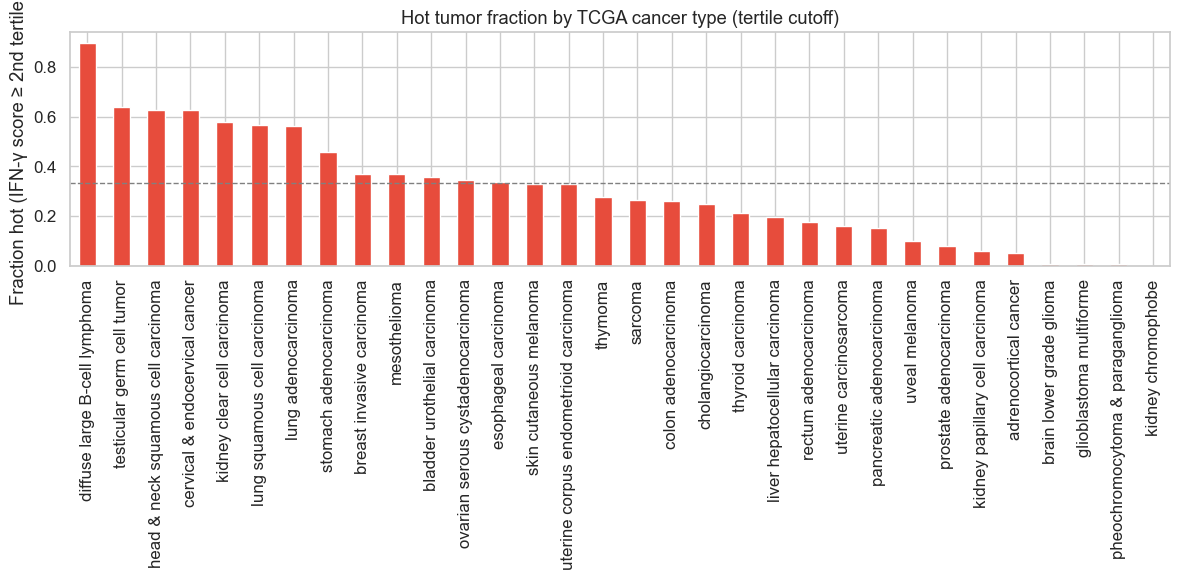

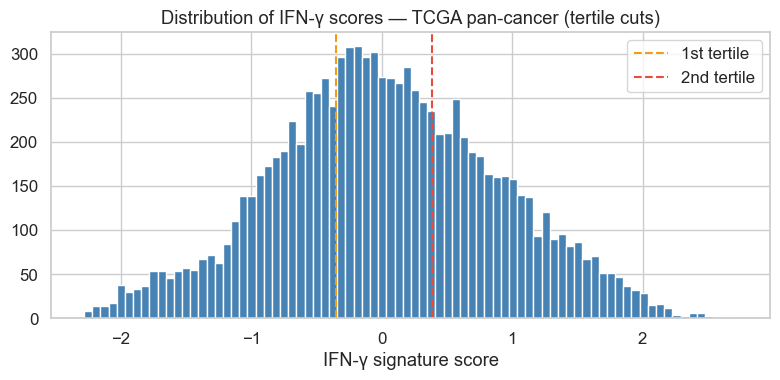

In [6]:
if "tumor_type" in immune.columns:
    hot_frac = (
        immune.groupby("tumor_type")["hot_cold"]
        .apply(lambda s: (s == "hot").mean())
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    hot_frac.plot.bar(ax=ax, color="#e74c3c")
    ax.axhline(1/3, ls="--", color="gray", lw=1)
    ax.set_ylabel("Fraction hot (IFN-γ score ≥ 2nd tertile)")
    ax.set_title("Hot tumor fraction by TCGA cancer type (tertile cutoff)")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(FIGURES / "hot_fraction_by_tumor_type.png", dpi=150)
    plt.show()

# Distribution of IFN-γ scores with tertile thresholds
low_t, high_t = immune["ifng_score"].quantile([1/3, 2/3])
fig, ax = plt.subplots(figsize=(8, 4))
immune["ifng_score"].hist(bins=80, color="steelblue", ax=ax)
ax.axvline(low_t,  color="#f39c12", ls="--", label="1st tertile")
ax.axvline(high_t, color="#e74c3c", ls="--", label="2nd tertile")
ax.set_xlabel("IFN-γ signature score")
ax.set_title("Distribution of IFN-γ scores — TCGA pan-cancer (tertile cuts)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ifng_score_distribution.png", dpi=150)
plt.show()

## 6. Save Output

## 6. Join Thorsson Immune Subtypes (C1–C6)

In [7]:
# Load Thorsson immune subtype assignments
immune_subtype_file = DATA / "tcga_immune_subtypes.tsv.gz"
if immune_subtype_file.exists():
    immune_subtypes = pd.read_csv(
        immune_subtype_file, sep="\t", compression="gzip", index_col=0
    )
    # Normalise index to TCGA-XX-XXXX-01 format (same as we do for Thorsson CIBERSORT)
    def _norm(s):
        parts = str(s).replace(".", "-").split("-")
        if len(parts) >= 4:
            return "-".join(parts[:3]) + "-" + parts[3][:2]
        return s
    immune_subtypes.index = immune_subtypes.index.map(_norm)

    # Find the subtype column — varies by file version
    subtype_col = next(
        (c for c in immune_subtypes.columns
         if "subtype" in c.lower() or "immune" in c.lower()),
        immune_subtypes.columns[0]
    )
    print(f"Using subtype column: {subtype_col!r}")
    print(immune_subtypes[subtype_col].value_counts())

    immune = immune.join(
        immune_subtypes[[subtype_col]].rename(columns={subtype_col: "immune_subtype"}),
        how="left"
    )
    print(f"Immune subtype coverage: {immune['immune_subtype'].notna().sum():,} / {len(immune):,}")
else:
    print("Immune subtype file not found — run notebook 01 first.")
    immune["immune_subtype"] = pd.NA

Using subtype column: 'Subtype_Immune_Model_Based'
Subtype_Immune_Model_Based
IFN-gamma Dominant (Immune C2)       2591
Wound Healing (Immune C1)            2416
Inflammatory (Immune C3)             2397
Lymphocyte Depleted (Immune C4)      1157
Immunologically Quiet (Immune C5)     385
TGF-beta Dominant (Immune C6)         180
Name: count, dtype: int64
Immune subtype coverage: 9,271 / 9,862


## 7. Join Tumor Purity

In [8]:
purity_file = DATA / "tcga_purity.tsv"
if purity_file.exists():
    purity_df = pd.read_csv(purity_file, sep="\t")
    # Find sample ID column and purity column
    sample_col = next((c for c in purity_df.columns if "sample" in c.lower() or "barcode" in c.lower()), purity_df.columns[0])
    purity_col = next((c for c in purity_df.columns if "purity" in c.lower() or "absolute" in c.lower()), None)
    if purity_col:
        purity_series = purity_df.set_index(sample_col)[purity_col].rename("tumor_purity")
        # Normalise barcode if needed
        if purity_series.index[0].startswith("TCGA") and "." in purity_series.index[0]:
            def _norm_p(s):
                parts = str(s).replace(".", "-").split("-")
                return "-".join(parts[:3]) + "-" + parts[3][:2] if len(parts) >= 4 else s
            purity_series.index = purity_series.index.map(_norm_p)
        immune = immune.join(purity_series, how="left")
        print(f"Tumor purity coverage: {immune['tumor_purity'].notna().sum():,} / {len(immune):,}")
        print(f"Median purity: {immune['tumor_purity'].median():.2f}")
    else:
        print(f"Could not identify purity column in {list(purity_df.columns)}")
else:
    print("Purity file not found — run notebook 01 first.")
    immune["tumor_purity"] = pd.NA

Purity file not found — run notebook 01 first.


In [9]:
immune.to_parquet(DATA / "sample_immune_labels.parquet")
print(f"Saved {len(immune):,} samples → ../data/sample_immune_labels.parquet")
immune.dtypes

Saved 9,862 samples → ../data/sample_immune_labels.parquet


ifng_score        float64
cd8_fraction      float64
tumor_type         object
hot_cold           object
immune_subtype     object
tumor_purity       object
dtype: object